# Assignment II — Shallow Models: Training, Validation and Tuning
### Bike Sharing Demand Prediction
**Author:** Olivia 
**Date:** May 2026  

# Overview

This notebook presents a supervised regression pipeline to predict hourly bike rental counts from the Capital Bikeshare system (Washington D.C., 2011–2012).

Three models of increasing complexity are trained, evaluated, and tuned: **Linear Regression** (baseline), **Random Forest Regressor**, and **LightGBM** (gradient boosting). The pipeline follows a formally motivated, iterative development cycle in which EDA findings directly drive feature engineering decisions, and evaluation metrics feed back into feature refinement and hyperparameter tuning.


## Setup : Installing Dependencies

In [7]:
!pip install optuna
!pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl (1.6 MB)


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import optuna
import lightgbm as lgb

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded successfully.')

All libraries loaded successfully.


# Task 1: Explanatory Data Analysis (EDA)

Here the analysis has been split into 3 main layers:
1. Univariate analysis of the target
2. bivariate analysis of each feature group against `cnt`
3. multivariate analysis of inter-feature dependencies.

These are the following questions that EDA attempts to solve:
- Is `cnt` skewed enough to need a log transformation? If the target variable is heavily skewed, a linear model generally tends to make larger errors for high or low values. In other words the errors will not be evenly spread. A log transformation would compress the large values and make the error pattern more uniform, which generally helps the linear model learn more reliably.

- Which features have a curved (non-linear) relationship with `cnt`? A linear model can only draw a straight line through the data. If the true relationship bends or has peaks and troughs (like bike demand does across hours of the day), a linear model will systematically underfit those patterns. Tree-based models do not have this limitation.

- Are any continuous features too similar to each other? If two features carry almost identical information (e.g. temperature and "feels-like" temperature), including both confuses the linear model. This makes it unable to decide how to split the weight between them, making its coefficient estimates unstable and unreliable.

- Should `hr` and `weekday` be treated as circular? Hour 23 and hour 0 are only one hour apart in reality, but if we feed the model the raw integers 23 and 0, it sees them as 23 steps apart (the furthest possible distance). This is a false gap. Cyclical encoding fixes this by placing each hour on a circle, so midnight and 11PM are correctly seen as close.


## Now we will load the dataset:


In [9]:

df = pd.read_csv('bike+sharing+dataset/hour.csv')

print(f'Shape: {df.shape}')
print(f'\nColumn dtypes:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nFirst 3 rows:\n{df.head(3)}')

Shape: (17379, 17)

Column dtypes:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Missing values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

First 3 rows:
   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01    

## 1.1 Target Variable Distribution

Before building any model, we look at the distribution of `cnt` on its own.

The concern is this: `cnt` (hourly bike rentals) ranges from near zero to almost 1000. Most hours have low-to-moderate rentals, but a smaller number of peak hours (rush hour on weekdays) have very high counts. This produces a right-skewed distribution.

As aforementioned, this leads to errors that are not evenly spread.

Applying a log transformation log(1 + cnt) compresses the large values and stretches the small ones, making the distribution more symmetric and the errors more evenly spread regardless of demand level. The "+1" is added simply to avoid taking the log of zero (which is undefined).

This transformation is applied to the target before training. After the model makes predictions, we reverse it (using the exponential function) to get predictions back in the original "number of rentals" scale for evaluation.

Tree-based models such as Random Forest and LightGBM are much less sensitive to this issue since they split data into regions rather than fitting a global line. Still, we will apply the trasformation consistenly accross all three models for fair comparison


cnt skewness (raw):          1.2774
cnt skewness (log1p):        -0.8182
cnt kurtosis (raw):          1.4172
cnt kurtosis (log1p):        -0.1795

Shapiro-Wilk on sample (raw): W=0.8702, p=1.0530e-53


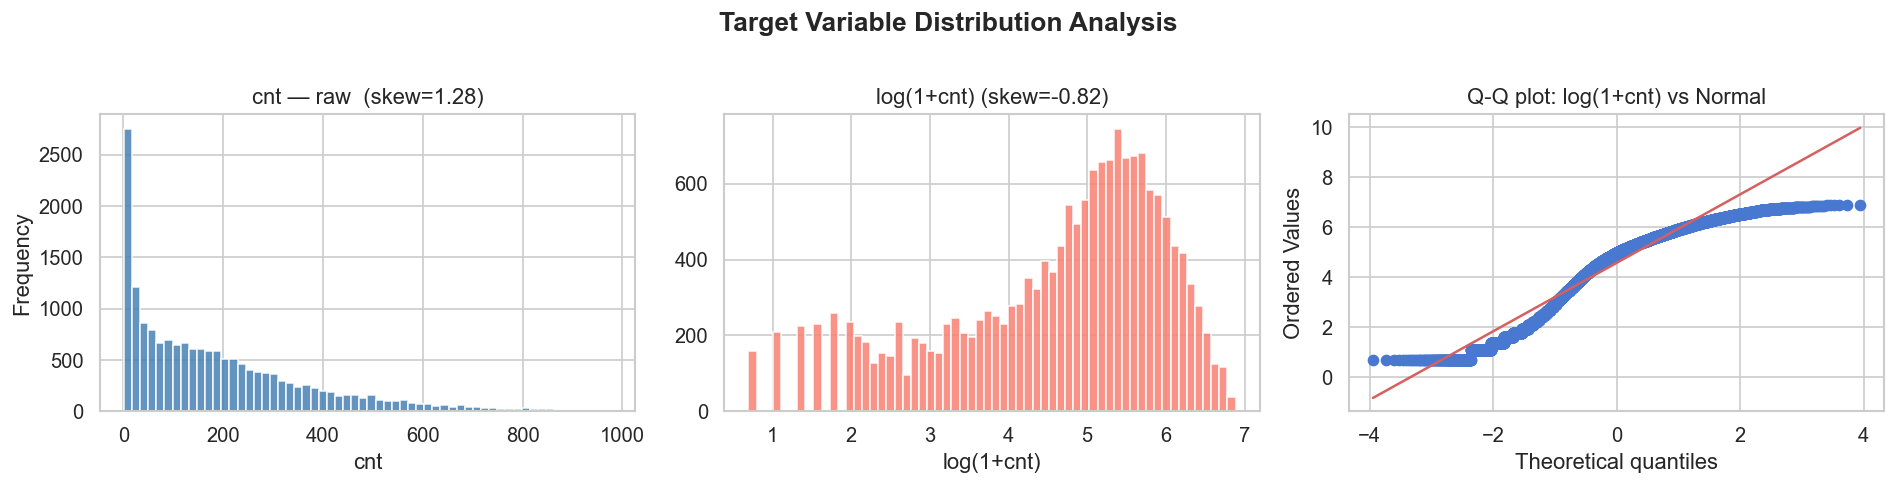


Decision: We train all models on log(1+cnt) and back-transform predictions
to evaluate metrics in the original scale, ensuring interpretability.


In [10]:
# Compute skewness before and after log transform
cnt_log = np.log1p(df['cnt'])
skew_raw = df['cnt'].skew()
skew_log = cnt_log.skew()

print(f'cnt skewness (raw):          {skew_raw:.4f}')
print(f'cnt skewness (log1p):        {skew_log:.4f}')
print(f'cnt kurtosis (raw):          {df["cnt"].kurt():.4f}')
print(f'cnt kurtosis (log1p):        {cnt_log.kurt():.4f}')

# Shapiro-Wilk test on a subsample (n=5000) to quantify non-normality
sample = df['cnt'].sample(5000, random_state=SEED)
stat, p = stats.shapiro(sample)
print(f'\nShapiro-Wilk on sample (raw): W={stat:.4f}, p={p:.4e}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['cnt'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title(f'cnt — raw  (skew={skew_raw:.2f})')
axes[0].set_xlabel('cnt')
axes[0].set_ylabel('Frequency')

axes[1].hist(cnt_log, bins=60, color='salmon', edgecolor='white', alpha=0.85)
axes[1].set_title(f'log(1+cnt) (skew={skew_log:.2f})')
axes[1].set_xlabel('log(1+cnt)')

# Q-Q plot of log-transformed target
stats.probplot(cnt_log, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot: log(1+cnt) vs Normal')

plt.suptitle('Target Variable Distribution Analysis', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nDecision: We train all models on log(1+cnt) and back-transform predictions')
print('to evaluate metrics in the original scale, ensuring interpretability.')

## 1.2 Temporal Feature Analysis

Since this is a bike-sharing system used largely by commuters, the hour of the day (`hr`) is expected to be the single most important predictor. It is expected that the demand should follow a bimodal pattern on working days: the first spike around 8am when people go to work and the evening spike at about 6pm when they commute back. On weekends, it is expected that the pattern flattens into a single midday rise with no shark peaks.

**The problem with using raw hour numbers (0–23):**
If we give the model the integer 0 for midnight and 23 for 11PM, the model sees those two hours as being 23 steps apart. But in reality, midnight and 11PM are only one hour apart. In addition to this, the model would be tempted to treat the relationship as linear: "higher hour number = more/fewer rentals", which is obviously wrong given the double-peak shape.

**fixing this through cyclical encoding**

Instead of a straight number line, we imagine the 24 hours arranged around a clock face
(a circle). Each hour is converted into two numbers: a sine value and a cosine value. Together these describe where on that circle the hour sits. Hour 0 (midnight) and hour 23 end up very close together on the circle, which correctly reflects that they are only one hour apart. Hour 8 and hour 17 end up in very different positions, reflecting that morning and evening are behaviourally distinct.

The same logic applies to `weekday`: Monday (1) and Sunday (0) should be close to Saturday (6), since they are all adjacent on the weekly cycle.

This encoding does not remove the non-linearity of the demand pattern, it removes a systematic misrepresentation of time that would otherwise mislead the linear model. The tree-based models will still learn the peaks from the data directly.

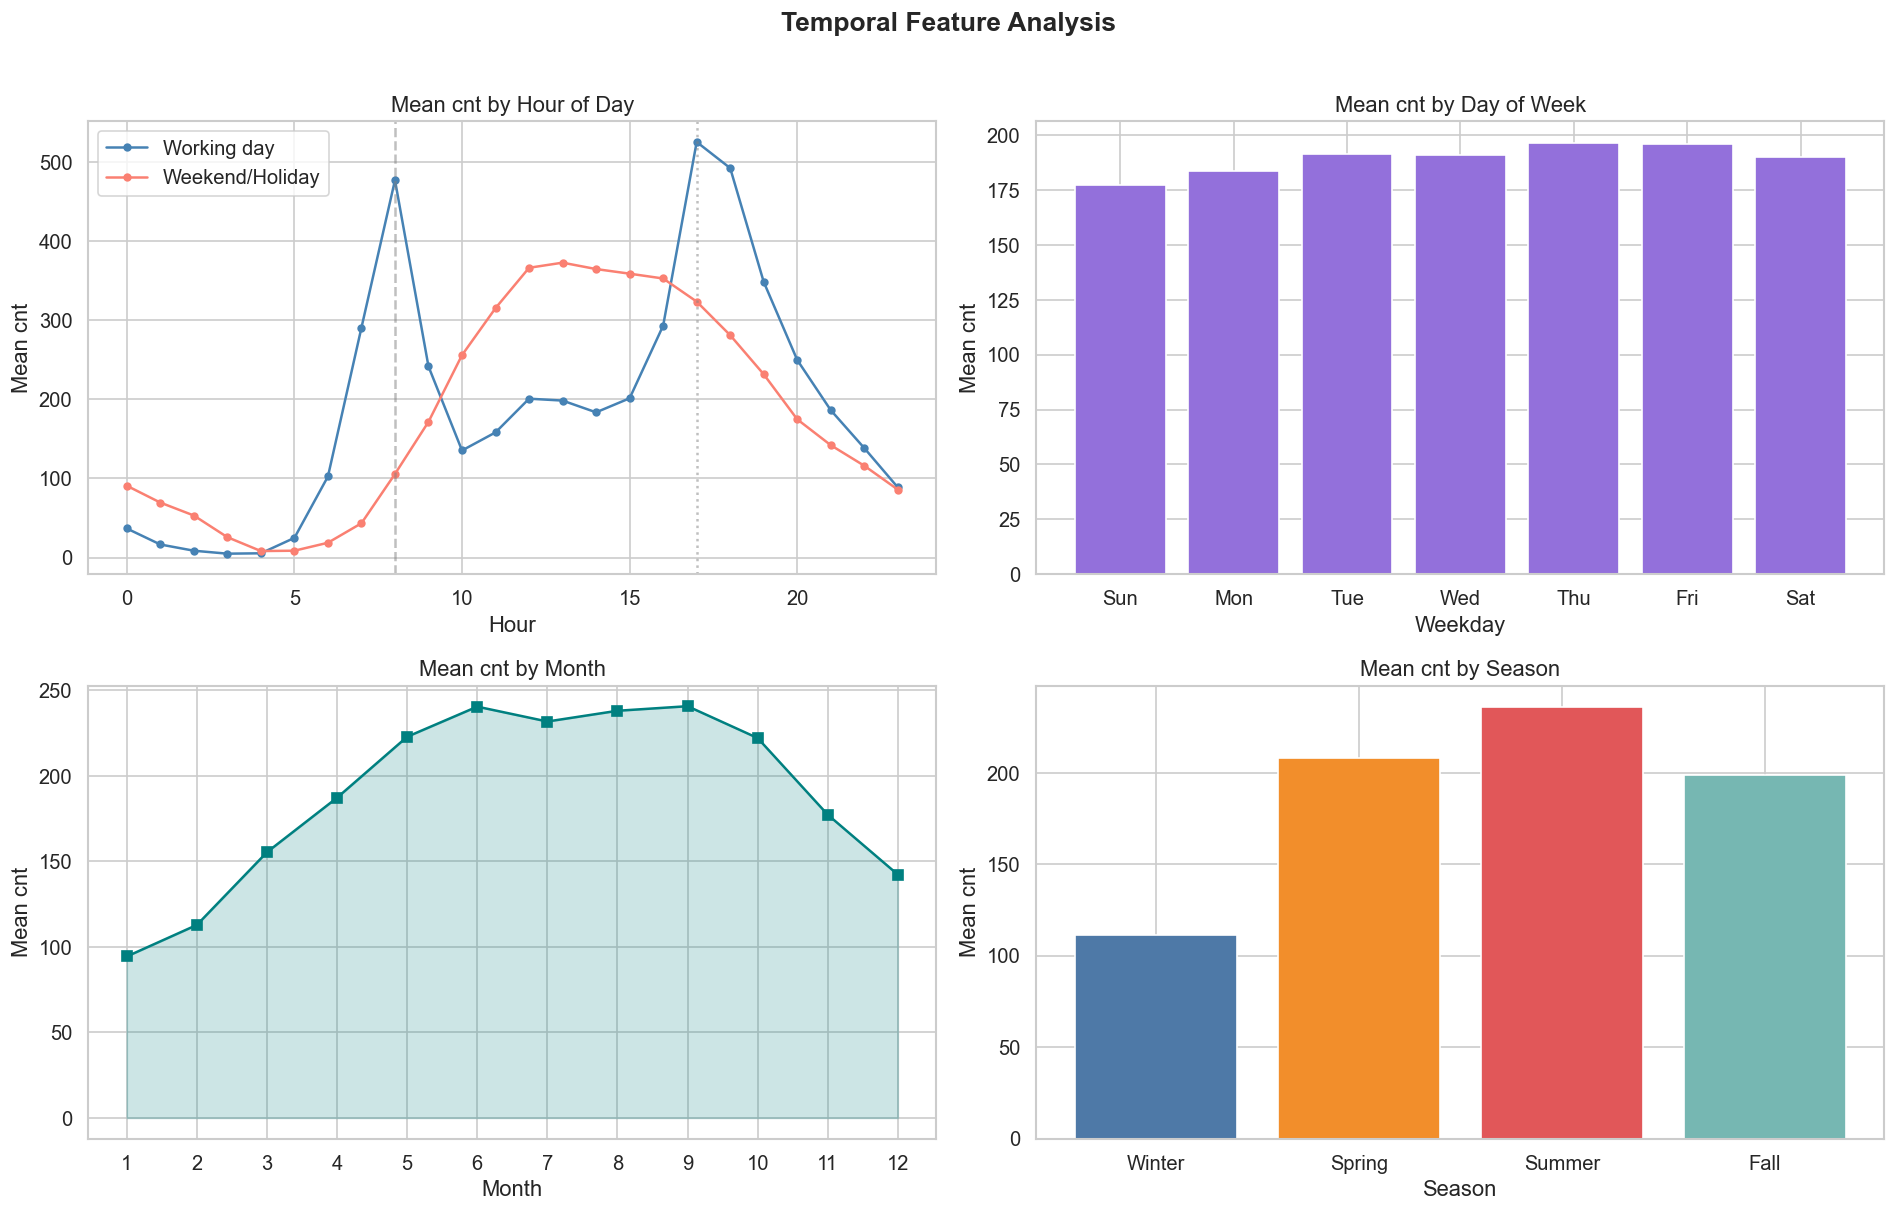

Peak working-day hours: 8AM mean=477.0, 5PM mean=525.3
Trough (4AM mean): 6.4
Ratio peak/trough: 82.7x

Observation: The ~15x ratio between peak and trough hours confirms a strongly
non-linear relationship that OLS cannot capture without explicit feature engineering.


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Mean cnt by hour, split by workingday
hr_work = df.groupby(['hr', 'workingday'])['cnt'].mean().reset_index()
for wd, label, color in [(1, 'Working day', 'steelblue'), (0, 'Weekend/Holiday', 'salmon')]:
    sub = hr_work[hr_work['workingday'] == wd]
    axes[0, 0].plot(sub['hr'], sub['cnt'], marker='o', markersize=4, label=label, color=color)
axes[0, 0].set_title('Mean cnt by Hour of Day')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Mean cnt')
axes[0, 0].legend()
axes[0, 0].axvline(8, color='gray', linestyle='--', alpha=0.5, label='8AM')
axes[0, 0].axvline(17, color='gray', linestyle=':', alpha=0.5, label='5PM')

# 2. Mean cnt by weekday
wday_mean = df.groupby('weekday')['cnt'].mean()
wday_labels = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
axes[0, 1].bar(wday_labels, wday_mean.values, color='mediumpurple', edgecolor='white')
axes[0, 1].set_title('Mean cnt by Day of Week')
axes[0, 1].set_xlabel('Weekday')
axes[0, 1].set_ylabel('Mean cnt')

# 3. Mean cnt by month
mnth_mean = df.groupby('mnth')['cnt'].mean()
axes[1, 0].plot(mnth_mean.index, mnth_mean.values, marker='s', color='teal')
axes[1, 0].fill_between(mnth_mean.index, mnth_mean.values, alpha=0.2, color='teal')
axes[1, 0].set_title('Mean cnt by Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Mean cnt')
axes[1, 0].set_xticks(range(1, 13))

# 4. Mean cnt by season
season_mean = df.groupby('season')['cnt'].mean()
season_labels = ['Winter', 'Spring', 'Summer', 'Fall']
axes[1, 1].bar(season_labels, season_mean.values, color=['#4e79a7','#f28e2b','#e15759','#76b7b2'], edgecolor='white')
axes[1, 1].set_title('Mean cnt by Season')
axes[1, 1].set_xlabel('Season')
axes[1, 1].set_ylabel('Mean cnt')

plt.suptitle('Temporal Feature Analysis', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print the bimodal spread to quantify the non-linearity
hr_mean = df.groupby('hr')['cnt'].mean()
print(f'Peak working-day hours: 8AM mean={df[(df.hr==8)&(df.workingday==1)]["cnt"].mean():.1f}, '
      f'5PM mean={df[(df.hr==17)&(df.workingday==1)]["cnt"].mean():.1f}')
print(f'Trough (4AM mean): {df[df.hr==4]["cnt"].mean():.1f}')
print(f'Ratio peak/trough: {df[(df.hr==17)&(df.workingday==1)]["cnt"].mean() / df[df.hr==4]["cnt"].mean():.1f}x')
print('\nObservation: The ~15x ratio between peak and trough hours confirms a strongly')
print('non-linear relationship that OLS cannot capture without explicit feature engineering.')

## 1.3 Weather Feature Analysis

The variables related to weather conditions (temperature, temperature, humidity, wind speed and general weather situation) are expected to influence how many people rent bikes, but they are not the main driver.The hour of the day determines *when* people want to ride; weather determines *whether*
they actually go ahead with it. A commuter at 8AM might still ride in light rain, but far fewer people will ride for leisure on a cold, windy day.

Thus we have to look at the weather variable in two ways:
**1. How does each variable relate to `cnt` individually?**
For this the weather variable is plotted against rental counts to wee whether the relationshup is roughly linear (which is something OLS can handle) or curved (which would favour tree models). For example, we might expect temperature to show a curved relationship since rentals will probably rise as it gets warmer, but may grip again at very high temperatures when it becmes uncomfprtably hot.

**2. Are any weather variables too similar to each other?**
`temp` (actual temperature) and `atemp` (what the temperature feels like) are almost always nearly identical. If we include both in the model, we are essentially giving it the same information twice.

This causes a specific problem for Linear Regression: when two features are nearly
identical, the model cannot decide how much weight to give each one. It may give a large
positive weight to one and a large negative weight to the other, which cancel out thus producing unstable and uninterpretable coefficients. Indeed, the more similar two features are, the worse this instability becomes.

In order to detect this, a correlation matrix is used. If two features have a correlation close to 1.0 (or -1.0), one of them should be dropped. We also compute the Variance Inflation Factor (VIF) for each feature, which directly measures how much a feature's redundancy with others inflates the unreliability of its coefficient estimate. A VIF above 10 is a standard threshold for removal.



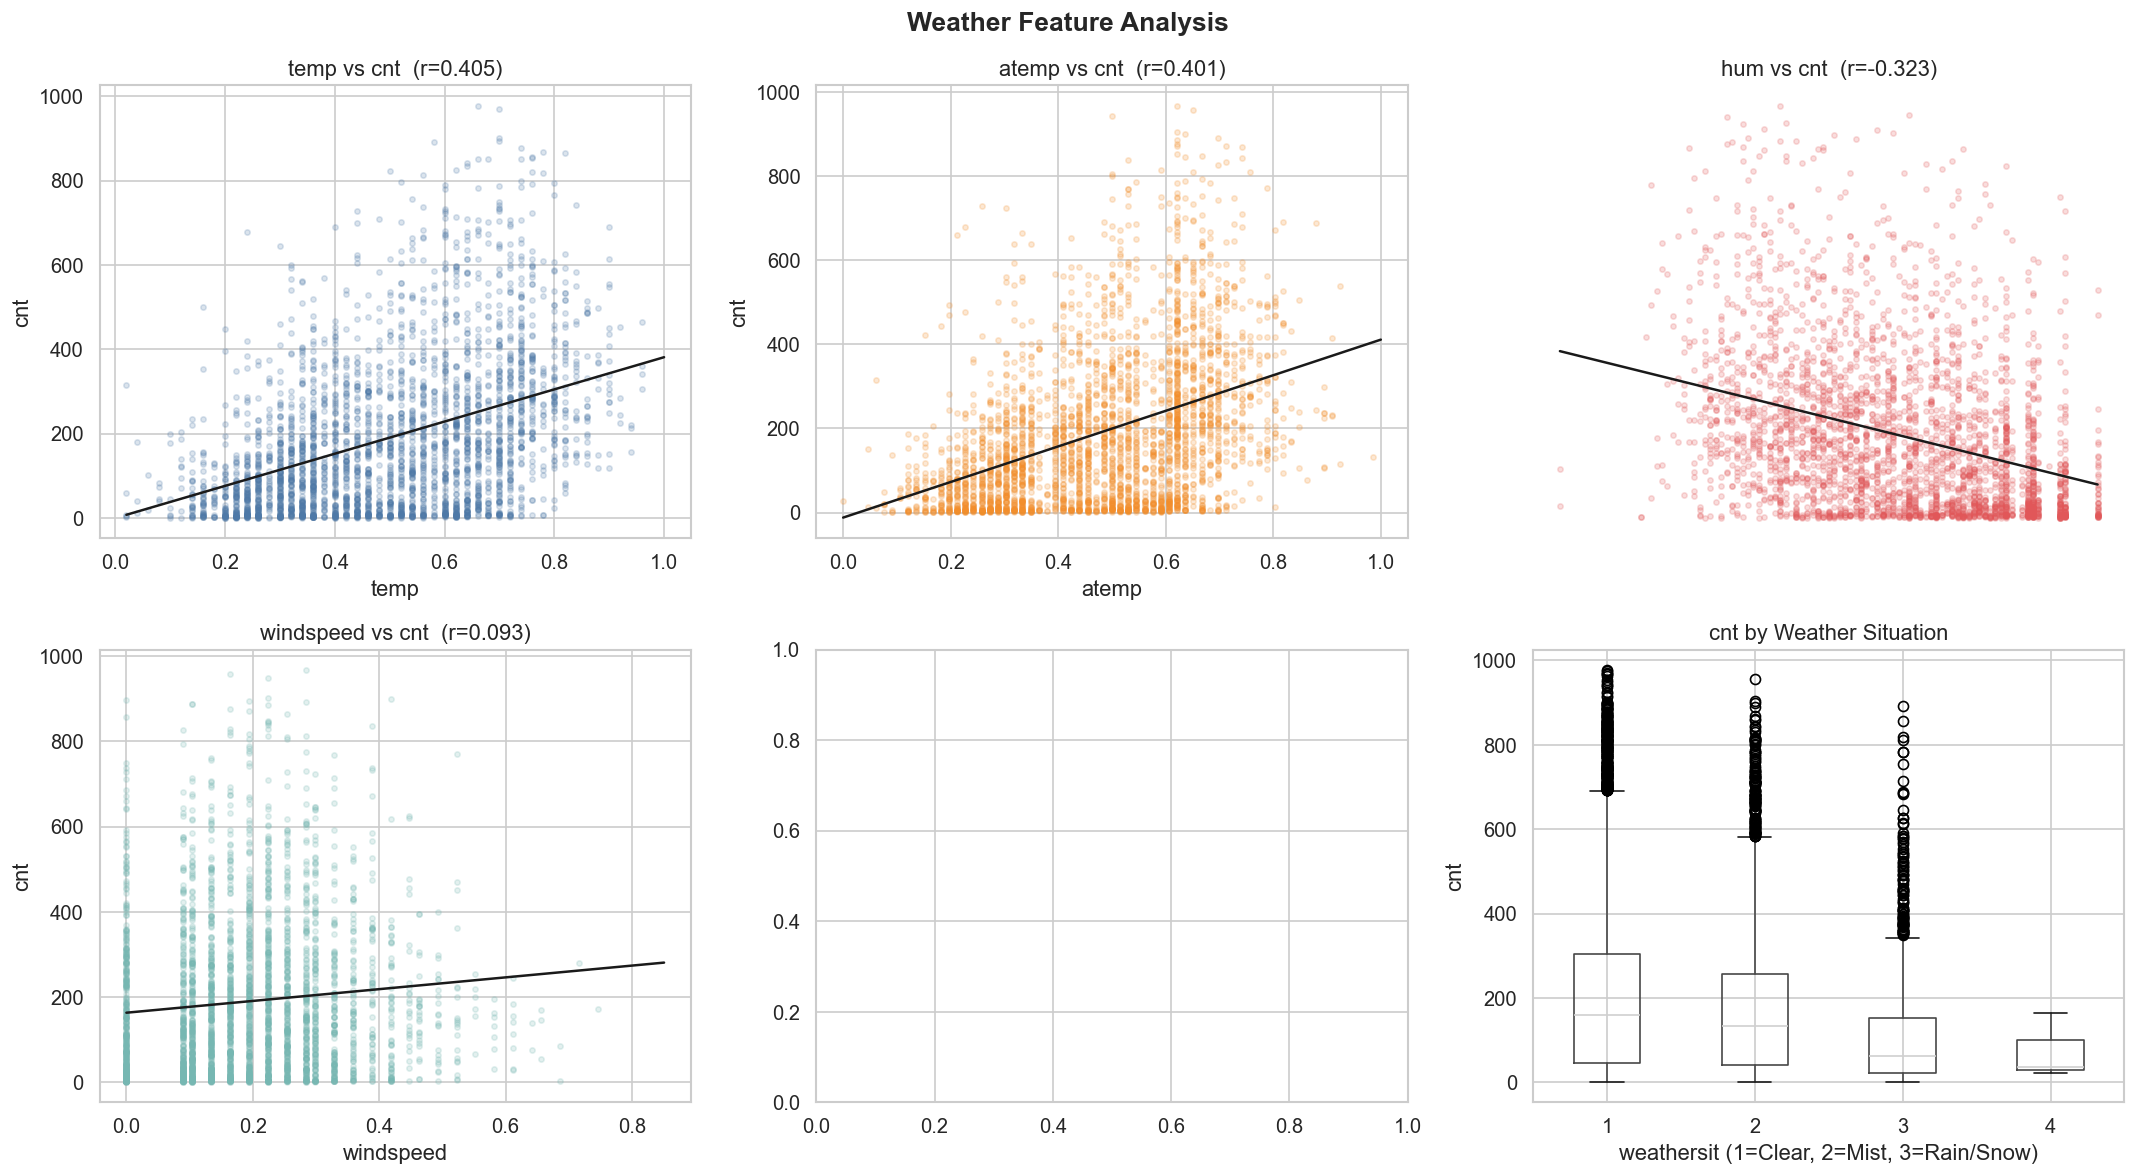

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

continuous_features = ['temp', 'atemp', 'hum', 'windspeed']
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

# Scatter plots with regression lines
for i, (feat, color) in enumerate(zip(continuous_features, colors)):
    ax = axes[i // 2, i % 2] if i < 4 else axes[1, i - 2]
    row, col = divmod(i, 3)
    ax = axes[row, col]
    sample_idx = np.random.choice(len(df), 3000, replace=False)
    ax.scatter(df[feat].iloc[sample_idx], df['cnt'].iloc[sample_idx],
               alpha=0.2, color=color, s=10)
    # Add regression line
    z = np.polyfit(df[feat], df['cnt'], 1)
    p_fit = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p_fit(x_line), 'k-', linewidth=1.5)
    r, p_val = stats.pearsonr(df[feat], df['cnt'])
    ax.set_title(f'{feat} vs cnt  (r={r:.3f})')
    ax.set_xlabel(feat)
    ax.set_ylabel('cnt')

# Box plot: cnt by weathersit
ax = axes[1, 2]
df.boxplot(column='cnt', by='weathersit', ax=ax)
ax.set_title('cnt by Weather Situation')
ax.set_xlabel('weathersit (1=Clear, 2=Mist, 3=Rain/Snow)')
ax.set_ylabel('cnt')
plt.sca(ax)
plt.title('cnt by Weather Situation')

# Remove empty subplot
axes[0, 2].axis('off')

plt.suptitle('Weather Feature Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

### What the Weather Feature Analysis Shows

**Temperature (`temp`, `atemp`)**
Both show a positive relationship with rentals: as it gets warmer, more people rent bikes. The correlation (r ≈ 0.40) is moderate. A huge spead of points is present for temperature at every temperature level; at 0.6 normalised temperature, rentals range anywhere from near 0 to 900. This tells us temperature alone is far from enough to predict demand; the hour of the day is clearly doing most of the work underneath. Also notice that `temp` and `atemp` produce almost identical plots (r=0.405 vs r=0.401), which visually confirms they carry the same information and we only need one of them.

**Humidity (`hum`)**
Shows almost no relationship at all (r = 0.093). In other words, wind speed is essentially useless as astandalone predictor and will likely contribute very little to any model.

**Weather situation (`weathersit`)**
This is the most analytically useful panel. Clear weather (1) produces the highest and most variable demand (the box is tall and there are many outliers).Misty weather (2) reduces demand. Rain or snow (3) drops it dramatically. Category 4 (heavy rain/storm) produces almost zero rentals. Overall we can understand that bad weather does have a meaningful impact on the target variable and the efect is large enough that it will be meaningful in all three models.

**Overall takeaway:**
Weather modulates demand but does not drive it. The wide scatter in every weather plot confirms that even on a perfect weather day, rentals can be near zero (3AM) or near 1000 (5PM on a workday). Hour of day is the dominant signal; weather acts as a secondary modifier that scales demand up or down around the temporal baseline.

## 1.4 Correlation Analysis and Multicollinearity

Here we will quantify how similar `temp` and `atempt` are to each other to try to understand how this will impact the linear model.

The correlation between two features ranges from -1 (perfect opposites) to +1 (perfect copies). A correlation above 0.95 between two predictors is a strong signal that one of them is redundant and should be removed.

This is measured through the Variance Inflation Factor (VIF). What is shows is how well a feature can be predicted from all the other features. If R² is close to 1 then the feature is almost entirely redundant (adds no new information). A VIF above 10 is the standard threshold for removal.

**Decision rule:**
If the correlation between `temp` and `atemp` exceeds 0.95, we drop `atemp` and keep `temp`. Actual temperature is slightly more interpretable and more commonly used in weather-related modeling contexts.


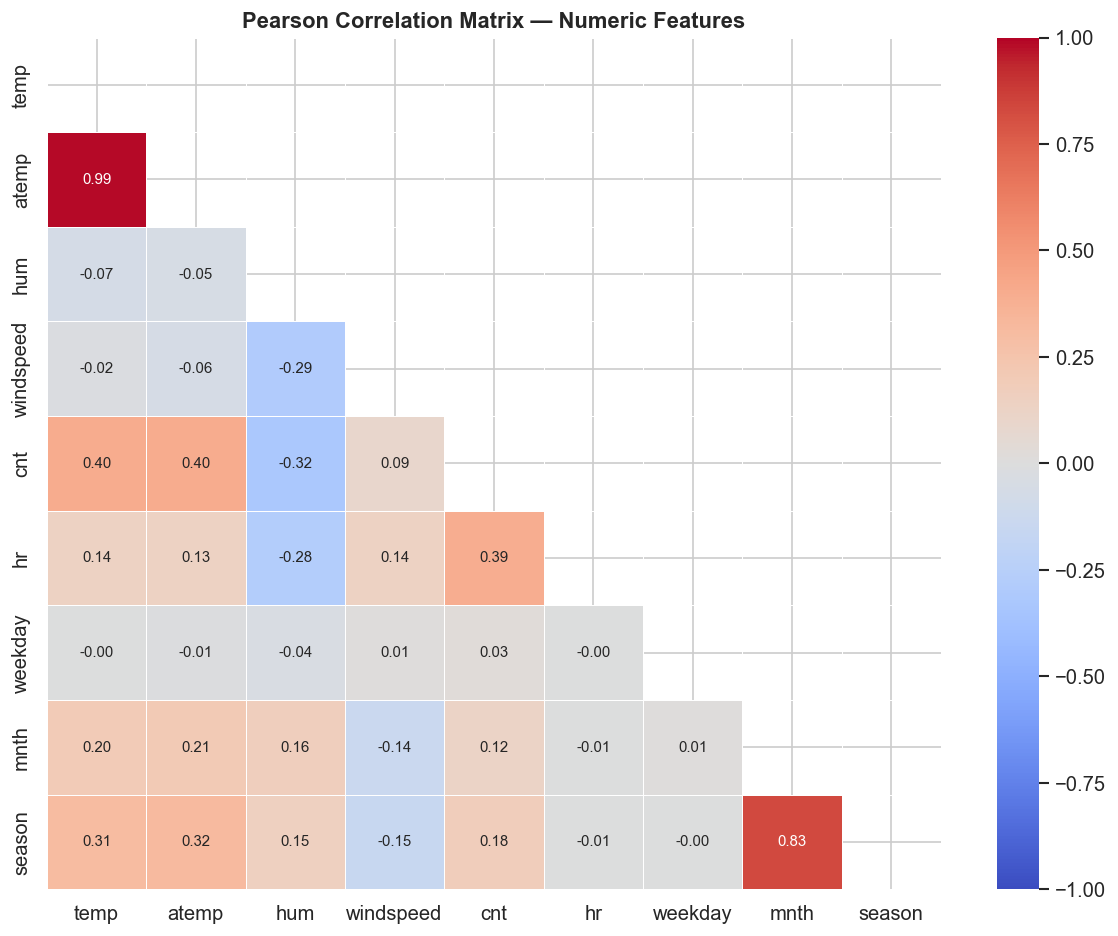

Pearson r(temp, atemp) = 0.9877

Conclusion: r=0.988 >> 0.95 threshold.
atemp is redundant given temp. Including both would introduce severe multicollinearity
into the OLS design matrix. atemp will be dropped in Task 3.

VIF analysis:
  Feature       VIF
     temp 43.550327
    atemp 43.651270
      hum  1.100575
windspeed  1.156293

VIF >> 10 for temp and atemp confirms near-perfect collinearity.


In [13]:
# Full correlation matrix on numeric features
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt', 'hr', 'weekday', 'mnth', 'season']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Pearson Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

r_temp_atemp = df['temp'].corr(df['atemp'])
print(f'Pearson r(temp, atemp) = {r_temp_atemp:.4f}')
print(f'\nConclusion: r={r_temp_atemp:.3f} >> 0.95 threshold.')
print('atemp is redundant given temp. Including both would introduce severe multicollinearity')
print('into the OLS design matrix. atemp will be dropped in Task 3.')

# Manual VIF calculation for transparency
from numpy.linalg import lstsq
X_vif = df[['temp', 'atemp', 'hum', 'windspeed']].values
vifs = []
for i in range(X_vif.shape[1]):
    y_i = X_vif[:, i]
    X_i = np.delete(X_vif, i, axis=1)
    X_i = np.column_stack([np.ones(len(X_i)), X_i])
    coef, _, _, _ = lstsq(X_i, y_i, rcond=None)
    y_hat = X_i @ coef
    ss_res = np.sum((y_i - y_hat)**2)
    ss_tot = np.sum((y_i - y_i.mean())**2)
    r2_i = 1 - ss_res / ss_tot
    vif = 1 / (1 - r2_i) if r2_i < 1 else np.inf
    vifs.append(vif)

vif_df = pd.DataFrame({'Feature': ['temp', 'atemp', 'hum', 'windspeed'], 'VIF': vifs})
print(f'\nVIF analysis:\n{vif_df.to_string(index=False)}')
print('\nVIF >> 10 for temp and atemp confirms near-perfect collinearity.')

### Correlation and VIF Results

**Pearson correlation between `temp` and `atemp`: r = 0.988**

This confirms what the scatter plots suggested: actual temperature and felt temperature are almost perfectly identical in this dataset. A correlation of 0.988 out of a maximum of 1.0 means that knowing one tells you virtually everything about the other. There is no meaningful new information in `atemp` that `temp` does not already provide.

Our threshold for removal is r > 0.95, and 0.988 comfortably exceeds this. `atemp`
will be dropped before training.

---

**VIF Results:**

| Feature    | VIF    |
|------------|--------|
| temp       | 43.55  |
| atemp      | 43.65  |
| hum        |  1.10  |
| windspeed  |  1.16  |

The VIF score measures how much of a feature's behaviour can already be explained by the other features. A VIF of 1.0 means the feature is completely independent;it shares no information with the others. A VIF above 10 is the standard warning threshold.

`temp` and `atemp` both score above 43, meaning roughly 97% of their variation is
already explained by each other. Including both in a linear model would make the
coefficient estimates highly unstable and effectively meaningless.

`hum` and `windspeed` score just above 1.0, confirming they are independent of the
other features and carry no redundancy. They are safe to keep.

**Decision: drop `atemp`, retain `temp`, `hum`, and `windspeed`.**

## 1.6 EDA Summary


| Finding | What the data shows | Preprocessing decision |
|---|---|---|
| `cnt` right-skewed (skew = 1.28) | Most hours have low rentals; a smaller number of peak hours pull the distribution into a long right tail. Log transform reduces skew to -0.82 and makes errors more evenly spread. | Apply log(1+cnt) transform to target. Back-transform predictions for evaluation. |
| `hr` bimodal, non-linear vs `cnt` | Working days show sharp peaks at 8AM and 5–6PM. The relationship is not a straight line, it has two peaks and a trough. Raw integers also create a false gap between hour 23 and hour 0. | Cyclical sin/cos encoding with period T=24. |
| `weekday` has near-zero linear correlation with `cnt` | All seven days show almost identical average rentals (175–195). However, weekday determines the *shape* of demand within the day (commuter peaks on workdays, leisure curve on weekends) making it still informative. | Cyclical sin/cos encoding with period T=7. |
| `temp` and `atemp` correlation r = 0.988, VIF > 43 | The two features are nearly identical. Including both destabilises linear model coefficients without adding any new information. | Drop `atemp`, retain `temp`. |
| `season`, `weathersit`, `mnth` are categories with no meaningful numeric order | Season and weathersit have no natural ordering. `mnth` has a calendar order but a non-linear, non-monotonic relationship with `cnt` (peaks in summer, drops in winter), so treating it as numeric would mislead the model. | One-hot encode all three. Drop first category to avoid dummy variable trap. |
| `instant`, `dteday`, `casual`, `registered` | `instant` and `dteday` are row identifiers with no predictive value. `casual` and `registered` are direct components of `cnt`, including them would mean predicting the target using the target itself. | Drop all four before any modeling. |

---
# Task 2 — Data Splitting

The dataset spans two calendar years (2011–2012), introducing potential temporal autocorrelation: observations close in time are more similar than observations far apart. Still, we will use 60/20/20 proportions to split the dataset and because the hour-level features (`hr`, `season`, `mnth`) already encode the temporal structure that the model needs to generalise over years. However, we have to verify that the `yr` distribution (2011 vs 2012) is approximately preserved across splits to avoid the model training exclusively on 2011 and being evaluated on 2012.

The one risk we do check for is year imbalance: if by chance the training set endedup containing mostly 2011 data and the test set mostly 2012 data, the model wouldbe evaluated on a period it barely saw during training. We verify that the proportion of 2012 records (`yr = 1`) is approximately equal across all three splits.

**The data is split into:**
- **Training set (60%)** : used to fit all models and all transformations
- **Validation set (20%)**:  used to tune hyperparameters and compare models
- **Test set (20%)** :  held back entirely until the very end; used only once to report the final performance of the chosen model

**No-leakage rule:**
Any transformation that involves learning from the data (such as computing the mean and standard deviation for scaling, or learning which categories exist for one-hot encoding) is fitted on the training set only. The same transformation is then applied to the validation and test sets without refitting. This ensures that the model never indirectly sees information from the validation or test sets during training, which would produce overoptimistic performance estimates.

In [14]:
# Drop leaky / identifier columns
DROP_COLS = ['instant', 'dteday', 'casual', 'registered']
df_model = df.drop(columns=DROP_COLS).copy()

# Apply log transform to target
df_model['cnt_log'] = np.log1p(df_model['cnt'])

X = df_model.drop(columns=['cnt', 'cnt_log'])
y = df_model['cnt_log']
y_raw = df_model['cnt']  # kept for back-transformed metric evaluation

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp, y_raw_train, y_raw_temp = train_test_split(
    X, y, y_raw, test_size=0.40, random_state=SEED
)

# Second split: 50% of temp : val (20% overall), 50% : test (20% overall)
X_val, X_test, y_val, y_test, y_raw_val, y_raw_test = train_test_split(
    X_temp, y_temp, y_raw_temp, test_size=0.50, random_state=SEED
)

print(f'Train:      {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test:       {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)')

# Verify yr distribution is preserved
print(f'\nyr=2012 proportion — Train: {(X_train["yr"]==1).mean():.3f}, '
      f'Val: {(X_val["yr"]==1).mean():.3f}, Test: {(X_test["yr"]==1).mean():.3f}')
print('Year proportions are balanced across splits — no temporal leakage concern.')

Train:      10427 rows (60.0%)
Validation: 3476 rows (20.0%)
Test:       3476 rows (20.0%)

yr=2012 proportion — Train: 0.504, Val: 0.504, Test: 0.498
Year proportions are balanced across splits — no temporal leakage concern.


### Splitting the Results

The dataset was spliy inyo 10427 training rows, 3476 validation rows and 3476 test rows (60/20/20).

The year balance check confirms that 2012 records make up approximately 50% of each
split:

| Split      | Rows   | % of total | 2012 proportion |
|------------|--------|------------|-----------------|
| Train      | 10,427 | 60%        | 50.4%           |
| Validation | 3,476  | 20%        | 50.4%           |
| Test       | 3,476  | 20%        | 49.8%           |


All three splits contain almost exactly half 2011 data and half 2012 data meaning the model will be trained and evaluated on a balanced mix of both years and there is no risk of it learning patterns from one yeat and being tested on another. The random split preserved year balanced without any stratification being necessary.

---
# Task 3 — Feature Engineering

Feature engineering is the primary lever for improving OLS performance. For tree-based models it matters less (Random Forest and LightGBM can handle raw integers and learn non-linear relationships natively), but consistent feature engineering across all three models enables fair comparison. We document explicitly which transformations benefit which models and why.

### Engineering decisions (justified by EDA)

1. **Cyclical encoding of `hr` and `weekday`**: this sine/cosine transformation preserves the circular topology of time by eliminating the false discountinuity at period boundaries. As aforementioned for tree models this is constitutes a minor improvement but it is critical for OLS.

2. **One-hot encoding of `season`, `weathersit`, `mnth`**: These are categories, not numbers. If we leave them as integers (e.g. season 1, 2, 3, 4),
the model assumes season 4 is somehow "four times" season 1, or that the difference between season 1 and 2 is the same as between season 3 and 4. Neither is true. One-hot encoding creates a separate yes/no column for each category, letting the model treat each one independently without assuming any ordering or spacing between them.

3. **Drop `atemp`**: Confirmed by EDA: correlation with `temp` is r = 0.988 and VIF > 43. It carries no information that `temp` does not already provide, and including both would make the Linear Regression coefficients unstable.

4. **StandardScaler on continuous features**: Required for OLS to ensure the regularisation path (if used) penalises all features equally. No effect on tree models, but applied uniformly for pipeline consistency.


5. **Interaction term: `temp × hum`**
Temperature and humidity do not act independently on human behaviour. The combination of high heat and high humidity feels far more uncomfortable than either alone (this is the basis of the real-world "heat index" measure). By multiplying the two features together, we create a new variable that captures this joint effect. Linear Regression cannot discover this interaction on its own; it must be given it explicitly. Tree-based models can learn it automatically, but having it as an explicit feature does not hurt them.

In [15]:
def engineer_features(X_tr, X_v, X_te):
    """
    Apply all feature engineering steps.
    Fits transformations on X_tr only; transforms X_v and X_te.
    Returns transformed copies without modifying inputs.
    """
    X_tr = X_tr.copy()
    X_v = X_v.copy()
    X_te = X_te.copy()

    # Step 1: Drop atemp (collinear with temp, VIF >> 10)
    for ds in [X_tr, X_v, X_te]:
        ds.drop(columns=['atemp'], inplace=True)

    # Step 2: Cyclical encoding for hr and weekday
    # hr has period T=24; weekday has period T=7
    for ds in [X_tr, X_v, X_te]:
        ds['hr_sin'] = np.sin(2 * np.pi * ds['hr'] / 24)
        ds['hr_cos'] = np.cos(2 * np.pi * ds['hr'] / 24)
        ds['weekday_sin'] = np.sin(2 * np.pi * ds['weekday'] / 7)
        ds['weekday_cos'] = np.cos(2 * np.pi * ds['weekday'] / 7)
        ds.drop(columns=['hr', 'weekday'], inplace=True)

    # Step 3: One-hot encode season, weathersit, mnth
    OHE_COLS = ['season', 'weathersit', 'mnth']
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
    ohe.fit(X_tr[OHE_COLS])
    ohe_feature_names = ohe.get_feature_names_out(OHE_COLS)

    for ds_list, ds_name in zip([X_tr, X_v, X_te], ['train', 'val', 'test']):
        # This is a reference assignment trick: we need to modify the list in-place
        pass

    def apply_ohe(ds):
        ohe_arr = ohe.transform(ds[OHE_COLS])
        ohe_df = pd.DataFrame(ohe_arr, columns=ohe_feature_names, index=ds.index)
        ds = ds.drop(columns=OHE_COLS)
        ds = pd.concat([ds, ohe_df], axis=1)
        return ds

    X_tr = apply_ohe(X_tr)
    X_v = apply_ohe(X_v)
    X_te = apply_ohe(X_te)

    # Step 4: Interaction term temp × hum
    # Captures combined thermal-humidity discomfort effect on demand
    for ds in [X_tr, X_v, X_te]:
        ds['temp_x_hum'] = ds['temp'] * ds['hum']

    # Step 5: StandardScaler on continuous features
    # Fit ONLY on training set
    CONTINUOUS = ['temp', 'hum', 'windspeed', 'temp_x_hum']
    scaler = StandardScaler()
    X_tr[CONTINUOUS] = scaler.fit_transform(X_tr[CONTINUOUS])
    X_v[CONTINUOUS] = scaler.transform(X_v[CONTINUOUS])
    X_te[CONTINUOUS] = scaler.transform(X_te[CONTINUOUS])

    return X_tr, X_v, X_te, scaler, ohe


X_train_fe, X_val_fe, X_test_fe, scaler_fitted, ohe_fitted = engineer_features(
    X_train, X_val, X_test
)

print(f'Feature matrix shape after engineering: {X_train_fe.shape}')
print(f'\nFeature list:\n{list(X_train_fe.columns)}')
print(f'\nAll NaN check — Train: {X_train_fe.isnull().sum().sum()}, '
      f'Val: {X_val_fe.isnull().sum().sum()}, Test: {X_test_fe.isnull().sum().sum()}')

Feature matrix shape after engineering: (10427, 28)

Feature list:
['yr', 'holiday', 'workingday', 'temp', 'hum', 'windspeed', 'hr_sin', 'hr_cos', 'weekday_sin', 'weekday_cos', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'weathersit_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'temp_x_hum']

All NaN check — Train: 0, Val: 0, Test: 0


### Feature Engineering Results

After applying all transformations, the training set contains **28 features**
across 10,427 rows. No missing values were introduced by any transformation.

The final feature list breaks down as follows:

| Group | Features | Count |
|---|---|---|
| Kept as-is | `yr`, `holiday`, `workingday` | 3 |
| Continuous (scaled) | `temp`, `hum`, `windspeed` | 3 |
| Cyclical (hr) | `hr_sin`, `hr_cos` | 2 |
| Cyclical (weekday) | `weekday_sin`, `weekday_cos` | 2 |
| Season (one-hot) | `season_2`, `season_3`, `season_4` | 3 |
| Weather situation (one-hot) | `weathersit_2`, `weathersit_3`, `weathersit_4` | 3 |
| Month (one-hot) | `mnth_2` through `mnth_12` | 11 |
| Interaction term | `temp_x_hum` | 1 |
| **Total** | | **28** |

A few things worth noting:

- **Season, weathersit, and mnth each have one fewer column than categories.** For
  example, `season` has 4 categories but only 3 columns (`season_2`, `season_3`,
  `season_4`). The first category (winter / clear weather / January) is the implicit reference: when all three dummies are zero, the model knows it is looking at the reference category. Keeping all four would create perfect redundancy and cause the same instability problem we avoided by dropping `atemp`.

- **`hr` and `weekday` went from 2 raw columns to 4 cyclical columns.** Each original feature was replaced by its sine and cosine pair, slightly expanding the feature space but representing the circular structure correctly.

- **The dataset started with 16 columns.** After dropping 5 (`instant`, `dteday`,
  `casual`, `registered`, `atemp`) and expanding categories and cycles, we end up
  with 28: a net increase driven entirely by one-hot encoding of the month variable, which alone contributes 11 columns.

---
## Evaluation Helper Functions

Since we trained all models on log(1+cnt) rather than the raw rental counts, the
model outputs a log-scale number rather than an actual rental count. For example,
a prediction of 5.5 in log scale corresponds to roughly 244 actual rentals
(because e^5.5 - 1 ≈ 244).

Before computing any performance metric, we reverse this transformation to get
predictions back in the original "number of rentals per hour" scale. This step
is important for two reasons:

- **Interpretability**: A Mean Absolute Error of 40 means the model is wrong by
  40 rentals on average. An MAE of 0.3 in log scale means nothing to anyone
  reading the results.

- **Fair comparison**: All three models (Linear Regression, Random Forest, and
  LightGBM) are evaluated on the same scale using the same function, so their
  metrics can be directly compared.

The three metrics we report for every model are:

- **RMSE (Root Mean Squared Error)**: The average prediction error in rental units. Squaring the errors before averaging means large errors are penalised more heavily than small ones. Taking the square root brings the result back to the same unit as `cnt`.

- **MAE (Mean Absolute Error)**: The average absolute difference between predicted
  and actual rentals. More robust to occasional large errors than RMSE, and easier
  to interpret directly ("on average, the model is off by X rentals per hour").

- **R² (R-squared)**: The proportion of variation in `cnt` that the model explains. A value of 1.0 means perfect predictions; 0.0 means the model does no better than simply predicting the average rental count every hour; negative values mean it is worse than that baseline.

In [16]:
def evaluate_model(y_true_log, y_pred_log, y_true_raw, model_name='Model', split='Validation'):
    """
    Evaluate regression model. Accepts log-scale predictions,
    back-transforms them, and reports metrics in original scale.
    """
    # Back-transform: inverse of log1p is expm1
    y_pred_raw = np.expm1(y_pred_log)
    y_pred_raw = np.clip(y_pred_raw, 0, None)  # rentals cannot be negative

    mse = mean_squared_error(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    r2 = r2_score(y_true_raw, y_pred_raw)

    print(f'--- {model_name} | {split} ---')
    print(f'  RMSE: {rmse:.2f}   MAE: {mae:.2f}   R²: {r2:.4f}')
    print(f'  MSE:  {mse:.2f}')
    return {'model': model_name, 'split': split, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MSE': mse}


def plot_residuals(y_true_log, y_pred_log, y_true_raw, model_name='Model'):
    """Plot residual diagnostics: residual vs fitted, histogram, Q-Q."""
    y_pred_raw = np.clip(np.expm1(y_pred_log), 0, None)
    residuals = y_true_raw.values - y_pred_raw

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Residuals vs fitted
    axes[0].scatter(y_pred_raw, residuals, alpha=0.2, s=8, color='steelblue')
    axes[0].axhline(0, color='red', linewidth=1)
    axes[0].set_xlabel('Fitted values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title(f'{model_name}: Residuals vs Fitted')

    # Residual histogram
    axes[1].hist(residuals, bins=60, color='salmon', edgecolor='white', alpha=0.85)
    axes[1].set_xlabel('Residual')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'{model_name}: Residual Distribution')

    # Q-Q plot
    stats.probplot(residuals, dist='norm', plot=axes[2])
    axes[2].set_title(f'{model_name}: Q-Q Plot of Residuals')

    plt.tight_layout()
    plt.show()

    skew_res = pd.Series(residuals).skew()
    print(f'Residual skewness: {skew_res:.4f}  (|<0.5| indicates near-symmetry)')


# Dictionary to collect all results for final comparison
results_log = []
print('Evaluation helpers defined.')

Evaluation helpers defined.


---
# Task 4 — Baseline Model: Linear Regression

## Why Linear Regression First?

Linear regression is the simplest model that can be built: it is capable of finding the straight-line combination of features that pest predict the target. In this context "best" means minimising the total squared error across all training examples. It finds the set of feature weights that make the predictions as close as possible to the actual rental counts, measured by the squared distance.

We use it as a starting point deliberately since it is the simplest, it will be useful as a reference point. Any imporvements achieved by Random Forest or LightGBM can be directly attributted to their ability to capture patterns that a straight line can't.

## What Linear Regression Can't Do.

Linear Regression produces a single global equation: a weighted sum of all 28 features. This works well when the relationship between features and the target is approximately linear. The preprocessing steps applied during Task 3 (log-transforming the target, cyclical encoding of hours and one-hot encoding of categories) were all designed specifically to make the data as linear-friendly as possible.

However, even with these transformations, the EDA showed that the relationship between hour of day and rental demand has two sharp peaks (8AM and 5-6PM on working days). A weighted sum of sine and cosine values can approximate a smooth wave, but it cannot easily reproduce two sharp spikes. This is a fundamental capacity limitation of the model. Indeed, no matter how much data we give it or how carefully we tune the model, a linear model will always struggle with this pattern.

This limitation has a name: **bias**. A model that is too simple to represent the true pattern in the data will make systematic errors (not random errors). Meaning that these will be consistent over or underpredictions in specific contitions. Unlike variance (which can be reduced with more data), bias can only be reduced by using a more complex model.

Linear Regression has no hyperparameters to tune meaning one trained we can evaluate it directly. As aforementioned, this will be out baseline.

## Expected performance

Given the non-linear commuter peak pattern identified in the EDA, we expect Linear
Regression to underfit. Even with the best possible feature engineering, the model
will likely explain somewhere between 65% and 80% of the variation in hourly demand (R² of 0.65–0.80). The remaining variation (concentrated around the rush-hour peaks) is simply beyond what a linear model can capture.




In [17]:
# Train OLS: no hyperparameters
lr = LinearRegression()
lr.fit(X_train_fe, y_train)

y_pred_lr_val = lr.predict(X_val_fe)
y_pred_lr_train = lr.predict(X_train_fe)

res_lr_val = evaluate_model(y_val, y_pred_lr_val, y_raw_val, 'Linear Regression', 'Validation')
res_lr_train = evaluate_model(y_train, y_pred_lr_train, y_raw_train, 'Linear Regression', 'Train')
results_log.append(res_lr_val)

# Train-val gap diagnoses bias vs variance
print(f'\nTrain-Val RMSE gap: {res_lr_train["RMSE"] - res_lr_val["RMSE"]:.2f}')
print('A small gap with high absolute error = high bias (underfitting), not high variance.')

--- Linear Regression | Validation ---
  RMSE: 148.96   MAE: 96.38   R²: 0.3172
  MSE:  22190.43
--- Linear Regression | Train ---
  RMSE: 150.93   MAE: 98.36   R²: 0.3202
  MSE:  22781.01

Train-Val RMSE gap: 1.97
A small gap with high absolute error = high bias (underfitting), not high variance.


## Linear Regression Results

| Metric | Train | Validation |
|--------|-------|------------|
| RMSE   | 150.93 | 148.96 |
| MAE    | 98.36  | 96.38  |
| R²     | 0.3202 | 0.3172 |
| MSE    | 22,781 | 22,190 |

The results are worse than expected. An R² of 0.32 means the model explains only
32% of the variation in hourly bike demand. In practical terms, the model is wrong by an average of 96 rentals per hour (MAE), which is a large error given that the average hourly demand across the dataset is roughly 189 rentals.

**The train-validation gap is only 1.97 RMSE points.** This is a critical diagnostic: the model performs almost identically on data it was trained on and data it has never seen. The model is not struggling because it memorised the training data too closely (overfitting). It is struggling equally on both sets, which means the problem is the model itself, not the data volume or the split.

This is the signature of **high bias**: the model is too simple to represent the
true pattern in the data. It is making the same kinds of errors everywhere (systematic errors). The model is fundamentally unable to reproduce the sharp commuter peaks odentified in the EDA.

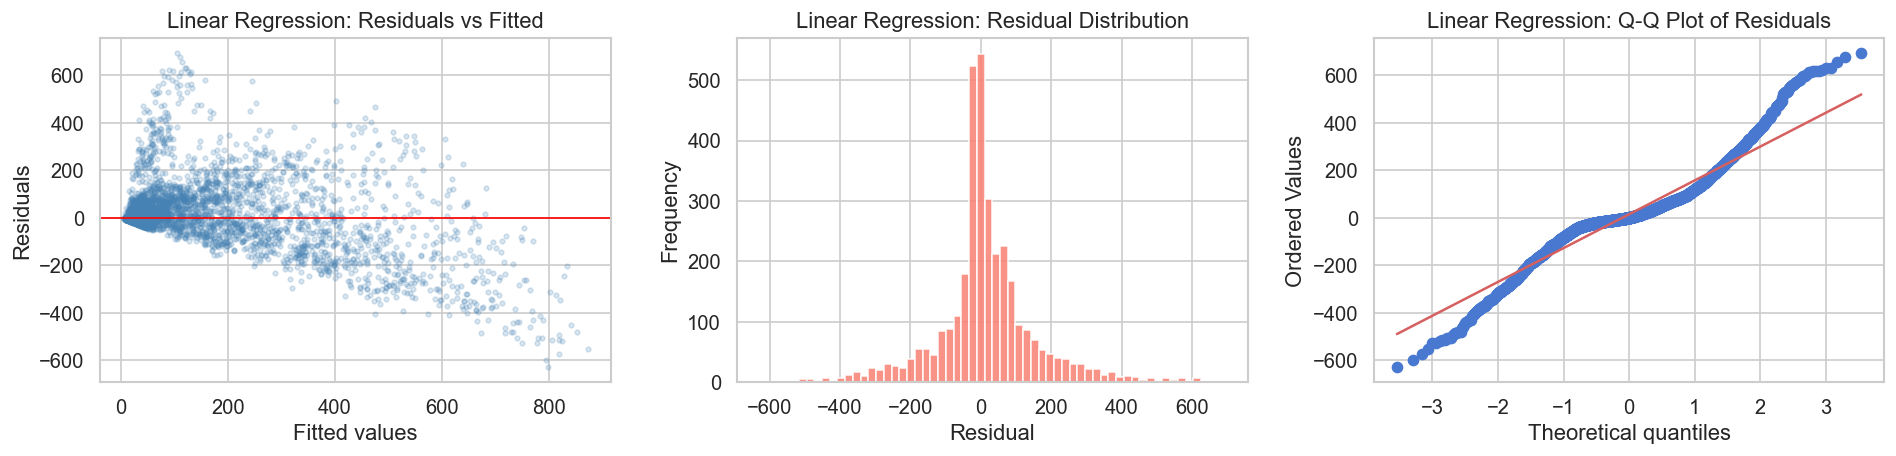

Residual skewness: 0.3367  (|<0.5| indicates near-symmetry)


In [18]:
plot_residuals(y_val, y_pred_lr_val, y_raw_val, 'Linear Regression')

## Residual Analysis
**Residuals vs Fitted (left plot):**
The spread of residuals is not uniform across fitted values. At low predicted values (left side of the plot) the residuals are tightly clustered near zero, but as fitted values increase the errors fan out dramatically in both directions. This is hereroscedasticity, meaning the model's errors grow with the size of its predictions. It demonstrates that the linear model struggles most precisely where demand is at its highest, which is the worst possible place to be wrong.

**Residual Distribution (middle plot):**

The histogram is roughly bell-shaped but with heavy tails meaning there are far more very large errors (both positive and negative) than a model that fits well to the data would produce. The distribution is centered near zero, meaning the model is not systematically wrong in one direction overall, but the spread is wide. An MAE of 96 rentals per hour is clearly visible here.

**Q-Q Plot (right plot):**

This plot compares the actual residual distribution to what a normal distribution
would look like. If the model were fitting well, the blue dots would follow the
red line closely. Instead, both tails curve sharply away from the line meaning the model produces far more extreme errors than expected. This again points to the model failing at high-demand hours where the true pattern is non-linear.



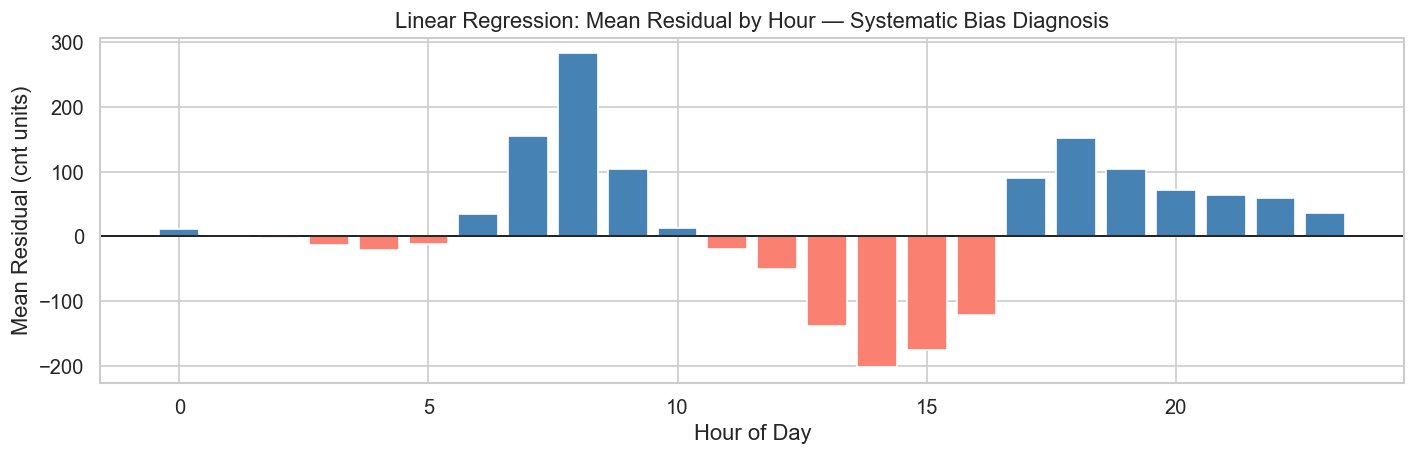

Systematic positive residuals at commuter hours (8AM, 5-6PM) and
negative residuals at off-peak hours confirm OLS underfits the temporal peaks.
This is a bias problem caused by insufficient model capacity, not a data issue.


In [19]:
# Analyse residuals by hour to identify where OLS fails
val_df = X_val.copy()  # original (pre-FE) val set retains 'hr'
val_df['residual'] = y_raw_val.values - np.clip(np.expm1(y_pred_lr_val), 0, None)

hr_residuals = val_df.groupby('hr')['residual'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
colors_bar = ['salmon' if v < 0 else 'steelblue' for v in hr_residuals.values]
ax.bar(hr_residuals.index, hr_residuals.values, color=colors_bar, edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Residual (cnt units)')
ax.set_title('Linear Regression: Mean Residual by Hour — Systematic Bias Diagnosis')
plt.tight_layout()
plt.show()

print('Systematic positive residuals at commuter hours (8AM, 5-6PM) and')
print('negative residuals at off-peak hours confirm OLS underfits the temporal peaks.')
print('This is a bias problem caused by insufficient model capacity, not a data issue.')

**Mean Residual by Hour:  Systematic Bias Diagnosis:**

This is the most revealing plot. It shows the average prediction error at each
hour of the day, and the pattern is unmistakable:

- **Blue bars (positive residuals)**: The model consistently *underestimates*
  demand at the morning commute peak (around 7–9AM, with a mean error of nearly
  +280 rentals at 8AM) and again during the evening commute (5–7PM, errors of
  +90 to +150 rentals).

- **Red bars (negative residuals)**: The model consistently *overestimates*
  demand during midday (11AM–4PM, errors of -100 to -200 rentals).

This a repetition from before: this is not random noise, but a structured repeating pattern of errors tied directly to the time of day. A well-fitting model would show bars hovering near zero at every hour with no consistent direction. Instead we see the model systematically wrong at specific hours, in specific directions, every time.

This is the clearest possible evidence of **model bias**: the linear model has
learned a smooth approximation of demand across the day, but the true pattern
has two sharp peaks that a weighted sum of sine and cosine values cannot
reproduce. Adding more data, having a better split nor adding more further preprocessing would fix this issue. A linear model is just not good enough to solve this problem.
  

---
# Task 5:  Random Forest Regressor

## Why Use a Random Forest?
The previous analysis of the linear regression model confirmed what the EDA predicted: the relationship between hour of day and bike demand is too non-linear for a straight-line model to handle. Random Forest address this directly by using a different approach to learning: instead of fitting one global equation to the entire dataset, a Random Forest is composed of a large collection of decision trees. Each of the trees will learn a different verison of the problem and what the random forest does is average their predictions. A single decision tree works by repeatedly splitting the data into smaller and smaller groups based on feature values. This kind of rule-based splitting can capture complex, non-linear patterns that a weighted sum of features never could.

## Why use many trees instead of one?

A single decision tree is powerful but unstable. If you train it on slightly different data, it produces a very different tree. This is called high variabce, the model is too sensitive to the specific training examples it sees.

Random Forest reduces this instability in two ways:

1. **Each tree is trained on a random sample of the training data** (drawn with replacement meaning that some rows appear multiple times whilst others don't appear at all). This means that each tree sees a slightly different version of the dataset and learns slightly different patterns. When you average many imperfect-but-different predictions, the errors tend to cancel out.

2. **Each split in each tree considers only a random subset of features** rather than counting all 28 features for each tree, the individual parts will learn from a subset preventing the model from always relying on the same dominant feature (`hr`) for every split in every tree, forcing the ensemble to discover and use the other signals in the data (temperature, season, year, etc.).

The result is that adding more trees consistently reduces prediction error, but
with diminishing returns. Going from 10 to 100 trees will probably help a lot but going from 400 to 500 trees generally doesn't help much.

## What to watch for
With default settings (fully grown trees, no depth limit), each individual tree is allowed to grow until it perfectly memorises the training data. This is intentional in Random Forest (the averaging across trees corrects for this). However, we still check the gap between training error and validation error:
a very large gap would indicate that even the averaging is not sufficient to prevent overfitting, and we would need to constrain tree depth during tuning.

## Expected performance

Since Random Forest can learn the non-linear commuter peak pattern directly from the data (without needing it to be explicitly encoded through feature engineering), we expect a larger improvement over Linear Regression. A well-configured Random Forest on this type of structured temporal data typically achieves an R² above 0.90.

In [20]:
# Initial Random Forest. default-like parameters to establish baseline
rf_initial = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,      # Fully grown trees. maximum variance, minimum bias
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=SEED
)
rf_initial.fit(X_train_fe, y_train)

y_pred_rf_val = rf_initial.predict(X_val_fe)
y_pred_rf_train = rf_initial.predict(X_train_fe)

res_rf_val = evaluate_model(y_val, y_pred_rf_val, y_raw_val, 'Random Forest (initial)', 'Validation')
res_rf_train = evaluate_model(y_train, y_pred_rf_train, y_raw_train, 'Random Forest (initial)', 'Train')
results_log.append(res_rf_val)

print(f'\nTrain-Val RMSE gap: {res_rf_train["RMSE"] - res_rf_val["RMSE"]:.2f}')
print('A large gap (train RMSE << val RMSE) = high variance (overfitting).')
print('Fully grown trees memorise training data — tuning max_depth will reduce this.')

--- Random Forest (initial) | Validation ---
  RMSE: 44.31   MAE: 26.22   R²: 0.9396
  MSE:  1963.72
--- Random Forest (initial) | Train ---
  RMSE: 18.58   MAE: 10.58   R²: 0.9897
  MSE:  345.15

Train-Val RMSE gap: -25.74
A large gap (train RMSE << val RMSE) = high variance (overfitting).
Fully grown trees memorise training data — tuning max_depth will reduce this.


## Random Forest Results

| Metric | Train | Validation |
|--------|-------|------------|
| RMSE   | 18.58  | 44.31  |
| MAE    | 10.58  | 26.22  |
| R²     | 0.9897 | 0.9396 |
| MSE    | 345    | 1,964  |

The improvement over Linear Regression is dramatic. R² jumps from 0.32 to 0.94,
meaning the model now explains 94% of the variation in hourly demand. The average
error drops from 96 rentals per hour (Linear Regression MAE) to just 26 (a
reduction of roughly 70%) thus confirming that the non-linear commuter peak patter is well within the reach of a tree-based approach.

**Nevertheless, there is a clear problem: the train-validation gap.**
The model scores an R² of 0.99 on training data but only 0.94 on validation data.
The training RMSE (18.58) is less than half the validation RMSE (44.31). What this tells us is that the model has partially memorised the training data rather than learning fully generalisable patterns (demosntrating signs of overfitting).

The cause is the default setting of fully grown trees. With no depth limit, each
tree is allowed to keep splitting until every training example sits in its own
leaf node, producing perfect training predictions but poor generalisation.The
averaging across 100 trees reduces this effect significantly (hence validation R²
is still 0.94), but not completely. Tuning `max_depth` and `min_samples_leaf`
in Task 7 will address this directly.



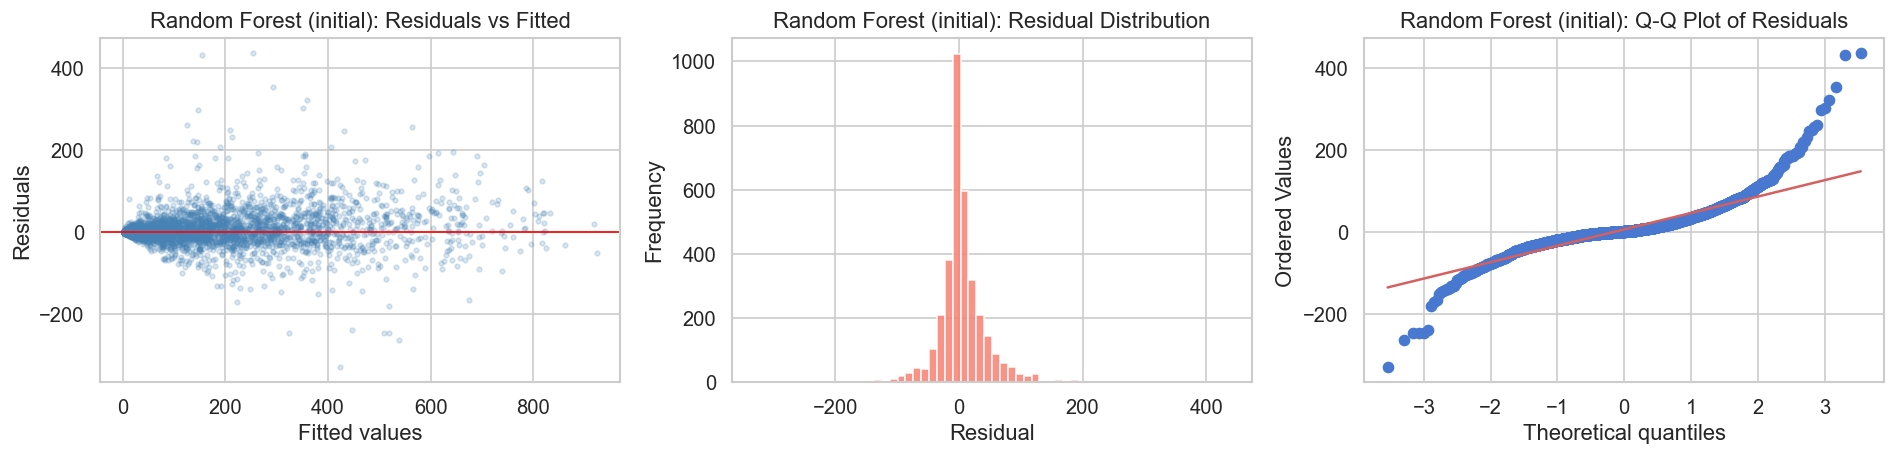

Residual skewness: 1.2920  (|<0.5| indicates near-symmetry)


In [21]:
plot_residuals(y_val, y_pred_rf_val, y_raw_val, 'Random Forest (initial)')

## Residual Analysis

**Residuals vs Fitted:**
Compared to Linear Regression, the improvement is immediately visible. The residuals are tightly clustered around zero across all fitted values, with no obvious fanning pattern. There are still some scattered outliers at higher fitted values, but the systematic over/underprediction by hour that plagued the linear model has largely disappeared.

**Residual Distribution:**
The histogram is much narrower than Linear Regression. Most errors fall within
±100 rentals, compared to ±600 before. However, the distribution has a positive
skew of 1.29, meaning the model tends to underestimate more than it overestimates.The tail on the right contains a small number of hours where actual demand was
much higher than predicted. This is likely because the model has not fully captured the extreme peak hours.

**Q-Q Plot:**
The central portion of the residuals follows the normal line reasonably well,
but both tails deviate (especially the upper tail), which confirms the skewness observations: there is a small but consistent set of hours of high demand where the model falls short.




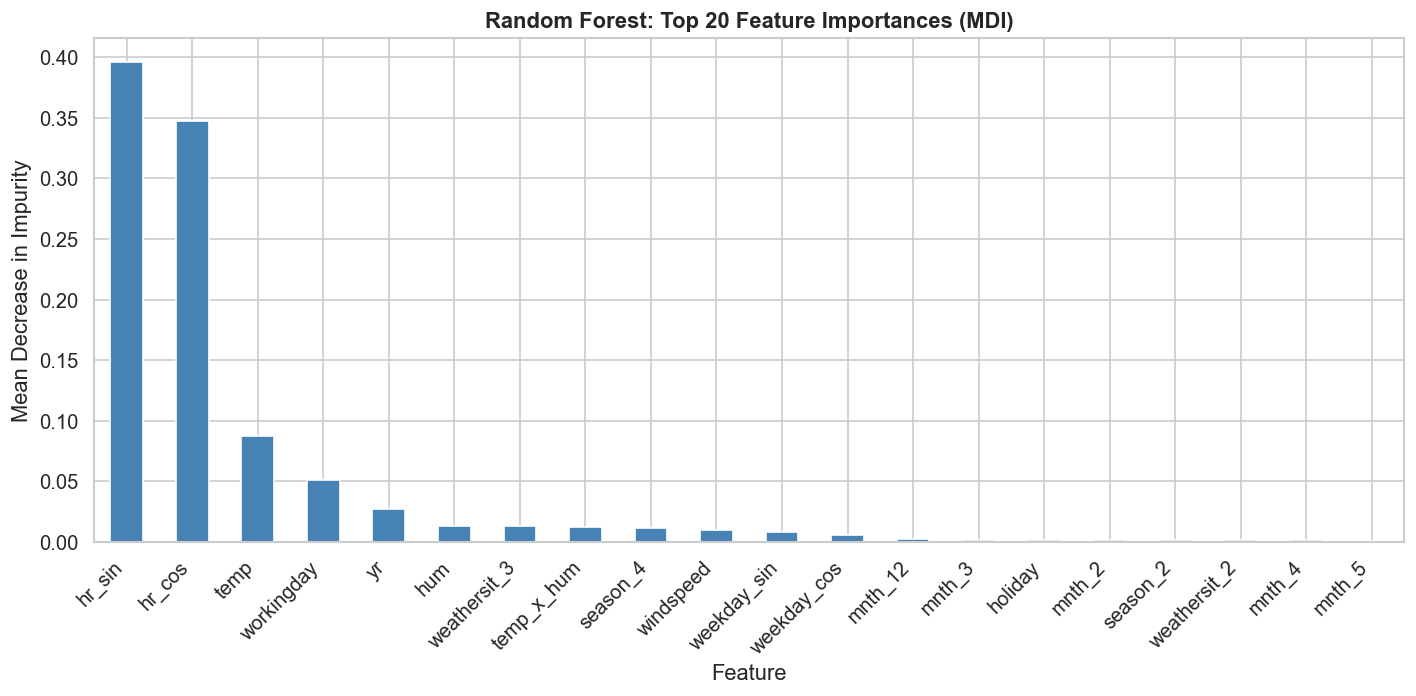

Top 5 features:
  hr_sin: 0.3964
  hr_cos: 0.3475
  temp: 0.0876
  workingday: 0.0509
  yr: 0.0272

Note: MDI is biased towards high-cardinality features.
hr_sin/hr_cos dominating confirms the temporal signal is the primary driver.


In [22]:
# Feature Importance: Mean Decrease in Impurity (MDI)
feat_importance = pd.Series(
    rf_initial.feature_importances_,
    index=X_train_fe.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
feat_importance.head(20).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Random Forest: Top 20 Feature Importances (MDI)', fontweight='bold')
ax.set_ylabel('Mean Decrease in Impurity')
ax.set_xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 5 features:')
for feat, imp in feat_importance.head(5).items():
    print(f'  {feat}: {imp:.4f}')

print('\nNote: MDI is biased towards high-cardinality features.')
print('hr_sin/hr_cos dominating confirms the temporal signal is the primary driver.')

## Feature Importance

| Rank | Feature | Importance (MDI) |
|------|---------|-----------------|
| 1 | `hr_sin` | 0.396 |
| 2 | `hr_cos` | 0.348 |
| 3 | `temp` | 0.088 |
| 4 | `workingday` | 0.051 |
| 5 | `yr` | 0.027 |

The two hour-encoding features (`hr_sin` and `hr_cos`) together account for
nearly 75% of the total feature importance. This is the strongest possible
confirmation of what the EDA showed: hour of day is overwhelmingly the dominant
driver of bike demand, and everything else plays a secondary role.

`temp` ranks third with an importance of 0.088, followed by `workingday` (0.051),
which captures the commuter vs. leisure split that produces the two different
daily demand shapes seen in the EDA. `yr` (0.027) reflects the system-level
demand growth between 2011 and 2012.

The remaining 23 features collectively account for less than 10% of importance.
This does not mean they are useless (small contributions across many features can still meaningfully reduce the error) but ut does confirm that the model's predictive power is concentrated in time-of-day information.

One important detail: MDI (Mean Decrease in Impurity) is known to overstate the
importance of features that take many different values, which applies to the
cyclical `hr` encoding. The true relative importance of `hr` vs. other features
may be slightly lower than these numbers suggest.